In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [2]:
viirs_night = pd.read_csv(
    "viirs_night_2023_2024_eda.csv"
)

print("Shape:", viirs_night.shape)

display(viirs_night.head())

Shape: (323659, 18)


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type,year,lat_grid,lon_grid
0,27.321,95.266,297.970,0.500,0.660,2023-01-01,1834,N,VIIRS,n,2,281.180,2.770,N,0,2023,27.300,95.200
1,27.321,95.267,295.170,0.500,0.660,2023-01-01,1834,N,VIIRS,n,2,281.390,1.710,N,0,2023,27.300,95.200
2,26.062,93.927,295.750,0.580,0.700,2023-01-01,1834,N,VIIRS,n,2,282.550,0.700,N,0,2023,26.000,93.900
3,31.086,77.808,310.170,0.560,0.430,2023-01-01,2014,N,VIIRS,n,2,276.500,3.020,N,0,2023,31.000,77.800
4,27.462,95.477,303.110,0.540,0.680,2023-01-01,2014,N,VIIRS,n,2,280.780,0.690,N,2,2023,27.400,95.400


In [3]:
viirs_night["acq_date"] = pd.to_datetime(
    viirs_night["acq_date"],
    errors="coerce"
)

print("Date range:")
print(viirs_night["acq_date"].min())
print(viirs_night["acq_date"].max())

Date range:
2023-01-01 00:00:00
2024-12-31 00:00:00


In [4]:
print("Nighttime VIIRS observations:", len(viirs_night))
print("Unique dates:", viirs_night["acq_date"].nunique())
print("Unique coordinates:",
      viirs_night[["latitude", "longitude"]].drop_duplicates().shape[0])

print("\nColumns:")
print(viirs_night.columns.tolist())

Nighttime VIIRS observations: 323659
Unique dates: 707
Unique coordinates: 323532

Columns:
['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'type', 'year', 'lat_grid', 'lon_grid']


In [5]:
viirs_night = viirs_night.drop(
    columns=["lat_grid", "lon_grid"],
    errors="ignore"
)

print(viirs_night.columns.tolist())

['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'type', 'year']


In [6]:
viirs_night = viirs_night.sort_values(
    ["latitude", "longitude", "acq_date", "acq_time"]
).reset_index(drop=True)

display(
    viirs_night[
        ["latitude", "longitude", "acq_date", "acq_time"]
    ].head(10)
)

,latitude,longitude,acq_date,acq_time
0,8.055,93.582,2023-06-23,1936
1,8.056,93.584,2023-06-23,1936
2,8.059,93.583,2023-06-23,1936
3,8.060,93.584,2023-06-23,1936
4,8.063,93.583,2023-06-23,1936
5,8.104,93.478,2023-04-05,1918
6,8.107,93.479,2023-04-05,1918
7,8.114,77.557,2023-05-09,2021
8,8.164,77.435,2023-06-29,2105
9,8.183,77.563,2024-03-30,2007


In [7]:
print("VIIRS nighttime dataset")
print("-" * 40)

print("Rows:", len(viirs_night))
print("Date range:",
      viirs_night["acq_date"].min().date(),
      "to",
      viirs_night["acq_date"].max().date())

print("Unique dates:", viirs_night["acq_date"].nunique())
print("Unique locations:",
      viirs_night[["latitude", "longitude"]].drop_duplicates().shape[0])

VIIRS nighttime dataset
----------------------------------------
Rows: 323659
Date range: 2023-01-01 to 2024-12-31
Unique dates: 707
Unique locations: 323532


In [8]:
events_eda = viirs_night.copy()

events_eda = events_eda[
    [
        "latitude",
        "longitude",
        "acq_date",
        "acq_time",
        "bright_ti4",
        "bright_ti5",
        "frp",
        "confidence",
        "daynight",
        "type"
    ]
].copy()

events_eda = events_eda.sort_values(
    ["acq_date", "latitude", "longitude"]
).reset_index(drop=True)

print("Working rows:", len(events_eda))

Working rows: 323659


In [10]:
daily_spatial = (
    events_eda
    .groupby("acq_date")
    .agg(
        detections=("latitude", "size")
    )
)

daily_spatial["unique_locations"] = (
    events_eda
    .groupby("acq_date")
    .apply(
        lambda x: x[["latitude", "longitude"]]
        .drop_duplicates()
        .shape[0]
    )
)

daily_spatial.head()

C:\Users\vinja\AppData\Local\Temp\ipykernel_26640\1145564934.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,detections,unique_locations
acq_date,,
2023-01-01,364,364
2023-01-02,344,344
2023-01-03,295,295
2023-01-04,345,345
2023-01-05,426,426


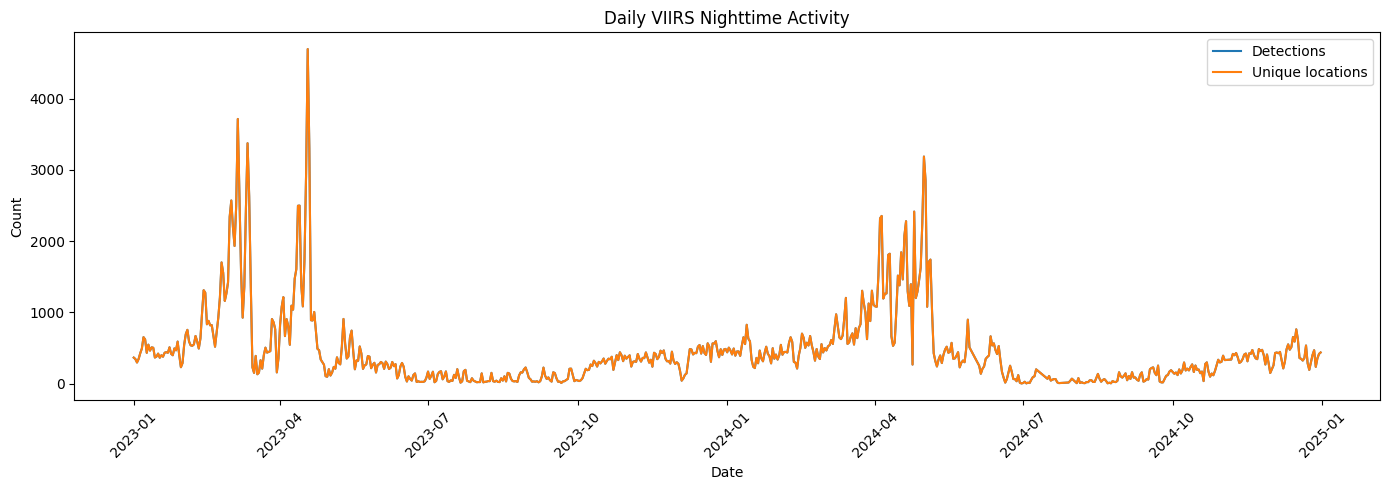

In [11]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_spatial.index,
    daily_spatial["detections"],
    label="Detections"
)

plt.plot(
    daily_spatial.index,
    daily_spatial["unique_locations"],
    label="Unique locations"
)

plt.title("Daily VIIRS Nighttime Activity")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
GRID_DEG = 0.01

events_eda["lat_grid"] = (
    np.floor(events_eda["latitude"] / GRID_DEG)
    * GRID_DEG
)

events_eda["lon_grid"] = (
    np.floor(events_eda["longitude"] / GRID_DEG)
    * GRID_DEG
)

events_eda[[
    "latitude",
    "longitude",
    "lat_grid",
    "lon_grid"
]].head()

,latitude,longitude,lat_grid,lon_grid
0,9.434,77.082,9.430,77.080
1,9.976,76.374,9.970,76.370
2,10.816,76.725,10.810,76.720
3,10.922,77.061,10.920,77.060
4,10.928,77.065,10.920,77.060


In [13]:
grid_density = (
    events_eda
    .groupby(["lat_grid", "lon_grid"])
    .size()
    .reset_index(name="detections")
)

print("Number of occupied spatial cells:",
      len(grid_density))

display(
    grid_density
    .sort_values("detections", ascending=False)
    .head(20)
)

Number of occupied spatial cells: 108702


,lat_grid,lon_grid,detections
40772,20.960,85.170,1804
69388,23.760,86.390,1802
41331,21.100,72.640,1473
68522,23.680,86.390,1464
69499,23.770,86.200,1327
41330,21.100,72.630,1317
69506,23.770,86.380,1307
69507,23.770,86.390,1307
9991,15.170,76.650,1242
40305,20.790,85.250,1204


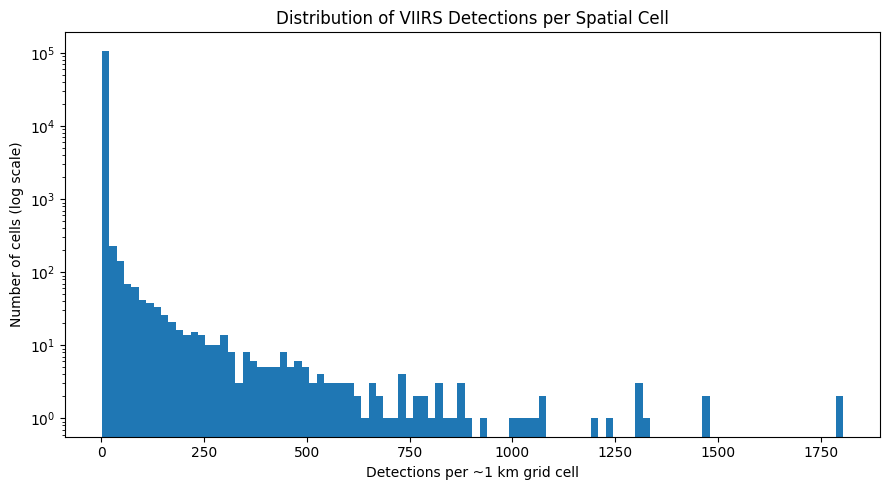

In [14]:
plt.figure(figsize=(9, 5))

plt.hist(
    grid_density["detections"],
    bins=100
)

plt.yscale("log")

plt.title("Distribution of VIIRS Detections per Spatial Cell")
plt.xlabel("Detections per ~1 km grid cell")
plt.ylabel("Number of cells (log scale)")

plt.tight_layout()
plt.show()

In [15]:
cell_temporal = (
    events_eda
    .groupby(["lat_grid", "lon_grid"])
    .agg(
        detections=("acq_date", "size"),
        active_days=("acq_date", "nunique"),
        first_date=("acq_date", "min"),
        last_date=("acq_date", "max")
    )
    .reset_index()
)

cell_temporal["calendar_span_days"] = (
    cell_temporal["last_date"]
    - cell_temporal["first_date"]
).dt.days + 1

cell_temporal.head()

,lat_grid,lon_grid,detections,active_days,first_date,last_date,calendar_span_days
0,8.050,93.580,3,1,2023-06-23,2023-06-23,1
1,8.060,93.580,2,1,2023-06-23,2023-06-23,1
2,8.100,93.470,2,1,2023-04-05,2023-04-05,1
3,8.110,77.550,1,1,2023-05-09,2023-05-09,1
4,8.160,77.430,1,1,2023-06-29,2023-06-29,1


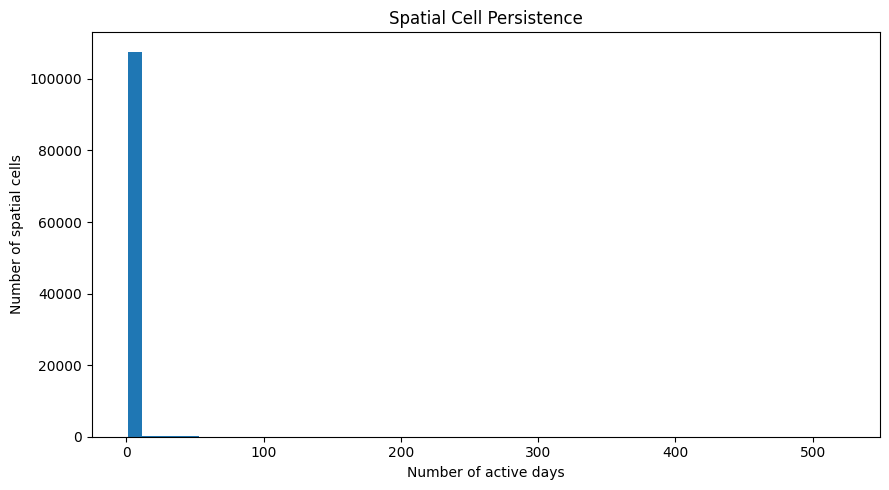

In [16]:
plt.figure(figsize=(9, 5))

plt.hist(
    cell_temporal["active_days"],
    bins=50
)

plt.title("Spatial Cell Persistence")
plt.xlabel("Number of active days")
plt.ylabel("Number of spatial cells")

plt.tight_layout()
plt.show()

In [17]:
cell_temporal[
    [
        "detections",
        "active_days",
        "calendar_span_days"
    ]
].describe()

,detections,active_days,calendar_span_days
count,108702.000,108702.000,108702.000
mean,2.977,2.163,39.312
std,25.479,14.224,121.770
min,1.000,1.000,1.000
25%,1.000,1.000,1.000
50%,1.000,1.000,1.000
75%,2.000,1.000,1.000
max,1804.000,523.000,731.000


In [18]:
print("Cells active on:")
print()

for threshold in [1, 3, 7, 14, 30, 60, 90, 180]:

    count = (
        cell_temporal["active_days"] >= threshold
    ).sum()

    print(
        f"{threshold:>3} days : "
        f"{count:,} cells"
    )

Cells active on:

  1 days : 108,702 cells
  3 days : 4,720 cells
  7 days : 1,320 cells
 14 days : 995 cells
 30 days : 713 cells
 60 days : 472 cells
 90 days : 352 cells
180 days : 187 cells


In [19]:
persistent_cells = cell_temporal[
    cell_temporal["active_days"] >= 30
].copy()

print(
    "Cells active ≥30 days:",
    len(persistent_cells)
)

display(
    persistent_cells
    .sort_values(
        ["active_days", "detections"],
        ascending=False
    )
    .head(30)
)

Cells active ≥30 days: 713


,lat_grid,lon_grid,detections,active_days,first_date,last_date,calendar_span_days
41331,21.100,72.640,1473,523,2023-01-01,2024-12-31,731
41330,21.100,72.630,1317,500,2023-01-02,2024-12-31,730
68522,23.680,86.390,1464,483,2023-01-01,2024-12-31,731
69619,23.780,86.200,783,472,2023-01-01,2024-12-31,731
69388,23.760,86.390,1802,467,2023-01-01,2024-12-31,731
69499,23.770,86.200,1327,461,2023-01-01,2024-12-31,731
69506,23.770,86.380,1307,454,2023-01-01,2024-12-31,731
40772,20.960,85.170,1804,453,2023-01-01,2024-12-31,731
69507,23.770,86.390,1307,452,2023-01-01,2024-12-30,730
69280,23.750,86.400,805,452,2023-01-01,2024-12-31,731


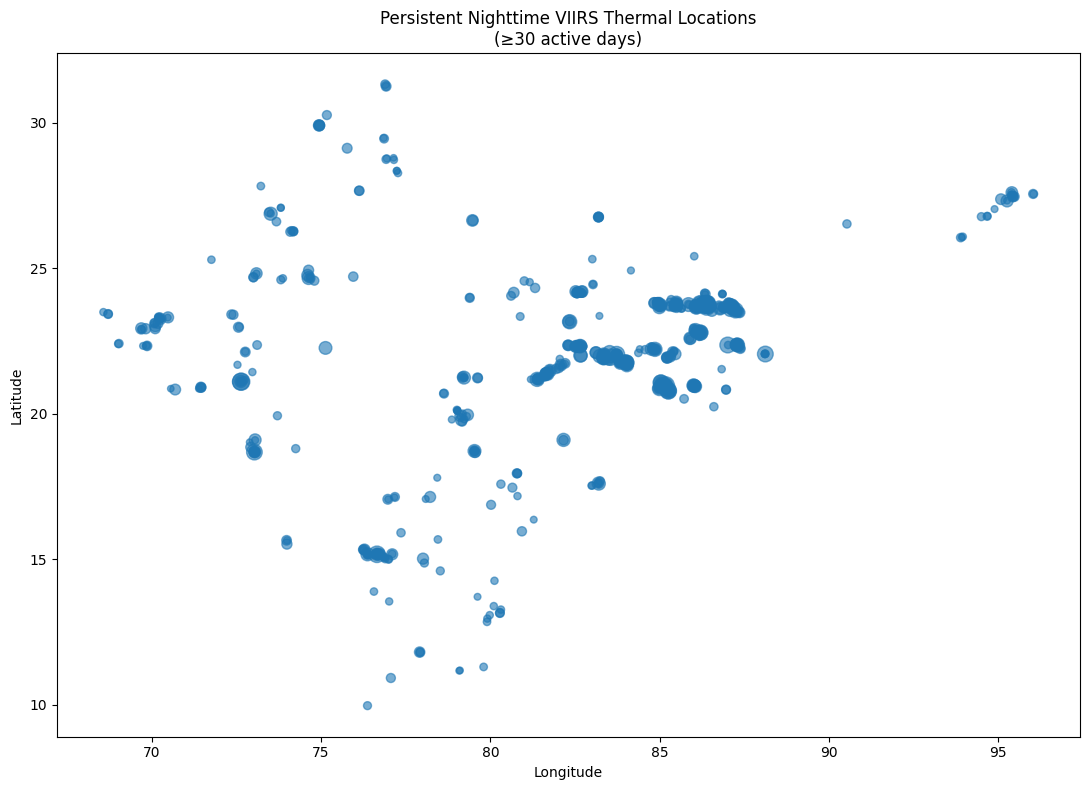

In [20]:
plt.figure(figsize=(11, 8))

plt.scatter(
    persistent_cells["lon_grid"],
    persistent_cells["lat_grid"],
    s=np.sqrt(
        persistent_cells["detections"]
    ) * 4,
    alpha=0.6
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Persistent Nighttime VIIRS Thermal Locations\n"
    "(≥30 active days)"
)

plt.tight_layout()
plt.show()

In [21]:
cell_dates = (
    events_eda[
        ["lat_grid", "lon_grid", "acq_date"]
    ]
    .drop_duplicates()
    .sort_values(
        ["lat_grid", "lon_grid", "acq_date"]
    )
    .copy()
)

cell_dates["previous_date"] = (
    cell_dates
    .groupby(["lat_grid", "lon_grid"])["acq_date"]
    .shift(1)
)

cell_dates["gap_days"] = (
    cell_dates["acq_date"]
    - cell_dates["previous_date"]
).dt.days

cell_dates.head(10)

,lat_grid,lon_grid,acq_date,previous_date,gap_days
128613,8.050,93.580,2023-06-23,NaT,NaN
128616,8.060,93.580,2023-06-23,NaT,NaN
80274,8.100,93.470,2023-04-05,NaT,NaN
115296,8.110,77.550,2023-05-09,NaT,NaN
128877,8.160,77.430,2023-06-29,NaT,NaN
216106,8.180,77.560,2024-03-30,NaT,NaN
96945,8.190,77.440,2023-04-17,NaT,NaN
294996,8.190,77.440,2024-10-02,2023-04-17,534.000
4974,8.190,77.640,2023-01-12,NaT,NaN
28059,8.190,77.640,2023-02-21,2023-01-12,40.000


In [22]:
gap_values = cell_dates["gap_days"].dropna()

print(gap_values.describe())

count   126472.000
mean        32.929
std         95.572
min          1.000
25%          1.000
50%          2.000
75%          7.000
max        727.000
Name: gap_days, dtype: float64


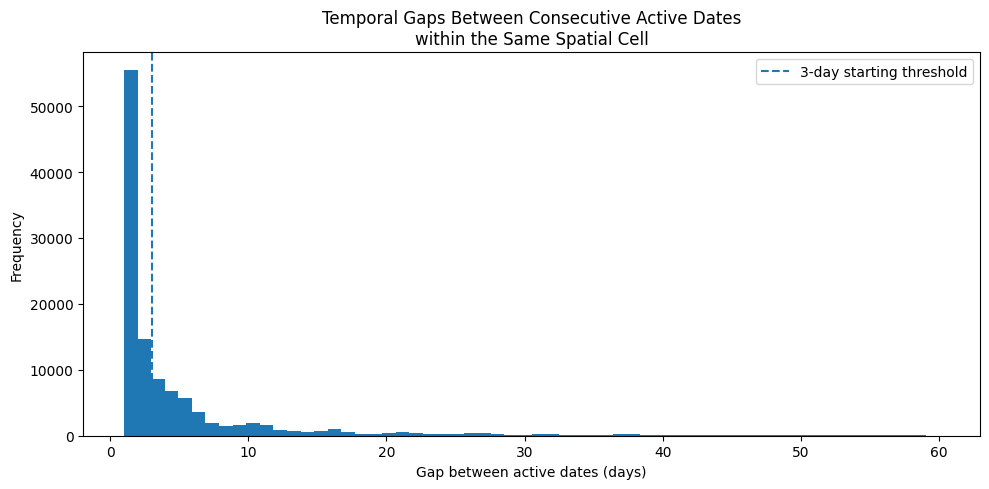

In [23]:
plt.figure(figsize=(10, 5))

plt.hist(
    gap_values[gap_values <= 60],
    bins=60
)

plt.axvline(
    3,
    linestyle="--",
    label="3-day starting threshold"
)

plt.title(
    "Temporal Gaps Between Consecutive Active Dates\n"
    "within the Same Spatial Cell"
)

plt.xlabel("Gap between active dates (days)")
plt.ylabel("Frequency")

plt.legend()
plt.tight_layout()
plt.show()

In [24]:
print("Temporal gap statistics")
print("-" * 40)

for threshold in [1, 2, 3, 5, 7, 14, 30]:

    percentage = (
        (gap_values <= threshold).mean()
        * 100
    )

    print(
        f"Gap ≤ {threshold:>2} days : "
        f"{percentage:6.2f}%"
    )

Temporal gap statistics
----------------------------------------
Gap ≤  1 days :  43.82%
Gap ≤  2 days :  55.41%
Gap ≤  3 days :  62.27%
Gap ≤  5 days :  72.16%
Gap ≤  7 days :  76.53%
Gap ≤ 14 days :  83.37%
Gap ≤ 30 days :  88.20%


In [25]:
cell_dates["new_episode"] = (
    cell_dates["gap_days"].isna()
    |
    (cell_dates["gap_days"] > 3)
)

cell_dates["episode_number"] = (
    cell_dates
    .groupby(["lat_grid", "lon_grid"])["new_episode"]
    .cumsum()
)

In [26]:
episode_summary = (
    cell_dates
    .groupby(
        [
            "lat_grid",
            "lon_grid",
            "episode_number"
        ]
    )
    .agg(
        start_date=("acq_date", "min"),
        end_date=("acq_date", "max"),
        active_days=("acq_date", "nunique")
    )
    .reset_index()
)

episode_summary["duration_days"] = (
    episode_summary["end_date"]
    - episode_summary["start_date"]
).dt.days + 1

episode_summary.head()

,lat_grid,lon_grid,episode_number,start_date,end_date,active_days,duration_days
0,8.050,93.580,1,2023-06-23,2023-06-23,1,1
1,8.060,93.580,1,2023-06-23,2023-06-23,1,1
2,8.100,93.470,1,2023-04-05,2023-04-05,1,1
3,8.110,77.550,1,2023-05-09,2023-05-09,1,1
4,8.160,77.430,1,2023-06-29,2023-06-29,1,1


In [27]:
episode_summary[
    [
        "active_days",
        "duration_days"
    ]
].describe()

,active_days,duration_days
count,156415.000,156415.000
mean,1.504,1.708
std,3.234,4.147
min,1.000,1.000
25%,1.000,1.000
50%,1.000,1.000
75%,1.000,1.000
max,156.000,182.000


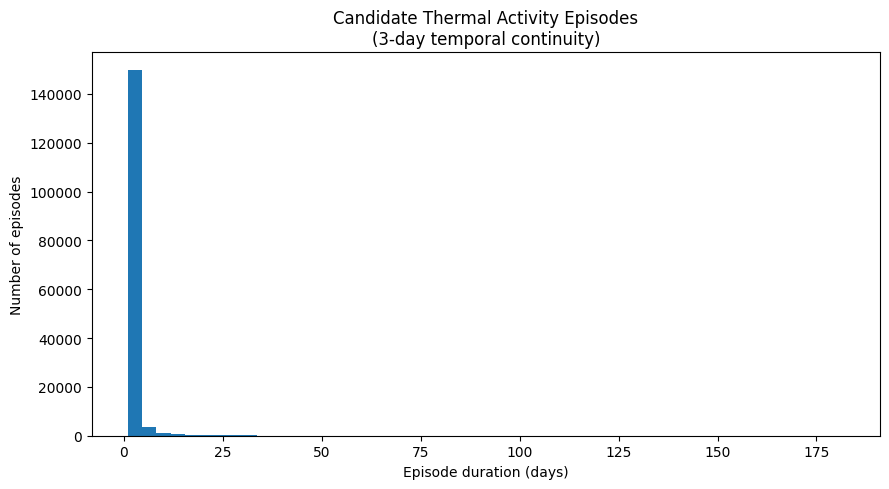

In [28]:
plt.figure(figsize=(9, 5))

plt.hist(
    episode_summary["duration_days"],
    bins=50
)

plt.title(
    "Candidate Thermal Activity Episodes\n"
    "(3-day temporal continuity)"
)

plt.xlabel("Episode duration (days)")
plt.ylabel("Number of episodes")

plt.tight_layout()
plt.show()

In [29]:
print(
    "Unique spatial cells:",
    cell_temporal.shape[0]
)

print(
    "Candidate episodes:",
    len(episode_summary)
)

print(
    "Average episodes per spatial cell:",
    round(
        len(episode_summary)
        / len(cell_temporal),
        2
    )
)

Unique spatial cells: 108702
Candidate episodes: 156415
Average episodes per spatial cell: 1.44


In [30]:
threshold_results = []

for threshold in [1, 2, 3, 5, 7, 14]:

    temp = cell_dates.copy()

    temp["new_episode"] = (
        temp["gap_days"].isna()
        |
        (temp["gap_days"] > threshold)
    )

    temp["episode_number"] = (
        temp
        .groupby(
            ["lat_grid", "lon_grid"]
        )["new_episode"]
        .cumsum()
    )

    n_episodes = (
        temp[
            [
                "lat_grid",
                "lon_grid",
                "episode_number"
            ]
        ]
        .drop_duplicates()
        .shape[0]
    )

    threshold_results.append(
        {
            "temporal_gap_days": threshold,
            "candidate_episodes": n_episodes
        }
    )

threshold_comparison = pd.DataFrame(
    threshold_results
)

display(threshold_comparison)

,temporal_gap_days,candidate_episodes
0,1,179749
1,2,165091
2,3,156415
3,5,143913
4,7,138388
5,14,129739


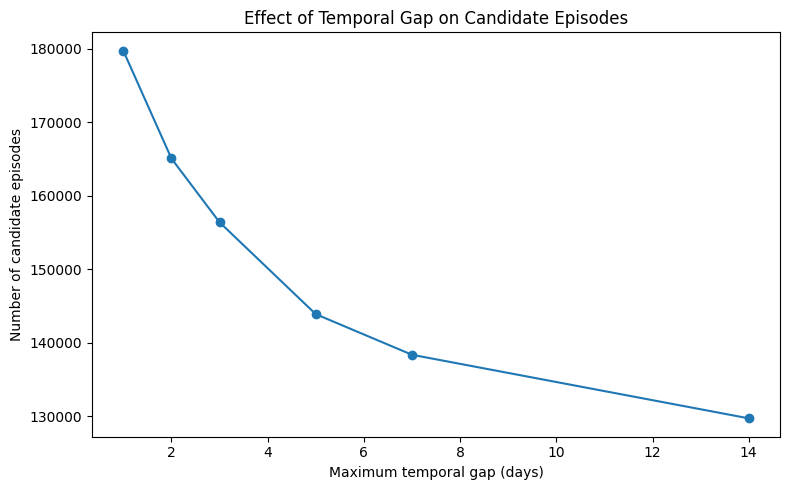

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_comparison["temporal_gap_days"],
    threshold_comparison["candidate_episodes"],
    marker="o"
)

plt.title(
    "Effect of Temporal Gap on Candidate Episodes"
)

plt.xlabel("Maximum temporal gap (days)")
plt.ylabel("Number of candidate episodes")

plt.tight_layout()
plt.show()

In [32]:
grid_density.to_csv(
    "viirs_spatial_grid_density.csv",
    index=False
)

cell_temporal.to_csv(
    "viirs_spatial_cell_temporal_stats.csv",
    index=False
)

cell_dates.to_csv(
    "viirs_spatial_cell_date_gaps.csv",
    index=False
)

episode_summary.to_csv(
    "viirs_candidate_episodes_3day.csv",
    index=False
)

threshold_comparison.to_csv(
    "viirs_temporal_threshold_comparison.csv",
    index=False
)

print("EDA diagnostic files saved.")

EDA diagnostic files saved.
